# Homework 4: Compartmental Models + Data Visualization (SPRING 2026)


# INSTRUCTOR VERSION

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, April 10th, 2026** 

It should be uploaded into D2L Homework #4.  Submission instructions can be found at the end of the notebook.

---
## Table of Contents

[Part 0. Academic Integrity Statement](#part_0) (2 points)

[Part 1. Understanding compartmental models](#part_1)  (20 points)

[Part 2. Simulating differential equations](#part_2)  (20 points)

[Part 3. Interpreting results of simulations](#part_3) (15 points)

[Part 4. Data visualization](#part_4) (20 points)

[Part 5. Data interpretation](#part_5) (16 points)

Total points = 93.

---
## Part 0. Academic integrity statement (2 points)

[Back to Top](#toc)

In the markdown cell below, paste your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

&#9998; *Put your personal academic integrity statement here.*

---
## Part 1. Understanding compartmental models (20 total points)

[Back to Top](#toc)


Malaria is caused by a parasite called _Plasmodium falciparum_, that undergoes several transformations during the lifecycle. After its initial form, sporozoites, penetrates the blood stream (thourgh a mosquito bite), it populates the liver where it produces the blood-stage called merozoites. Merozoites populate the red blood cells, and this is what causes the malaria symptoms. In this form however, the parasite is not transmissble. For transmission, another, non-replicating form, called gametocyte may develop through conversion from merozoites. The infection triggers response of immune effectors (i.e. white blood cells).

While the process is complicated, some general features may be learned through compartmental modeling. Examine the compartmental model diagram below.

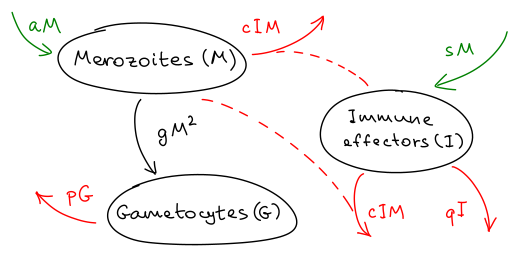

In [8]:
from IPython.display import SVG
SVG(filename='CMSE201_HW4_model.svg')


&#9989;&nbsp; **Part 1.1 (4 points)**

Describe in the cell below: how many compartments there are in the model, and what each of the compartments stands for. 

&#9998; *Put your answer here*

### ANSWER

* Three compartments (1pts).
* M represents the merozoites population (1 pts),
* G represents the gametocytes population (1 pts),
* I represents the immune effectors population (1 pts)

&#9989;&nbsp; **Part 1.2 (8 points)**

For each of the pathways or arrows in the model, give an interpretation for what actual process might be represented.

&#9998; *Put your answer here*

### ANSWER
Note: student answers might vary slightly but should make sense
- $a M$ (1pts): rate at which merozoites enter the system.
- $c I M$ (2pts): rate at which merozoites _and_ immune effectors exit the system.
- $s M$ (1pts): rate at which immune effectors enter the system.
- $q I$ (1pts): rate at which immune effectors exit the system.
- $p G$ (1pts): rate at which gametocytes exit the system.
- $g M^2$ (2pts): rate at which merozoites convert to gametocytes.

&#9989;&nbsp; **Part 1.3 (8 points)**

In the cell below, write down the ordinary differential equations associated with this compartmental model.

&#9998; *Put your answer here*

### ANSWER

$$
\frac{dM}{dt} = aM - cIM - gM^2
$$

$$
\frac{dG}{dt} = gM^2 - pG
$$

$$
\frac{dI}{dt} = sM - cIM - qI
$$


### Rubric (8 Points Total)

3 pts for any attempt to write the equations with the correct state variables.

5 pts for getting it right.

Formating doesn't matter.  

### ANSWER

THE MODEL IS SOLVED BELOW, BUT THIS IS NOT A PART OF THE EXERCISE **PART 1**, THIS ONLY DOCUMENTS THE MODEL FOR POSSIBLE EXPERIMENTATION

In [63]:
###ANSWER###
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [64]:
###ANSWER###

# The model is from this paper (with specific choices):
# F.Ellis McKenzie, William H. Bossert,
# The Dynamics ofPlasmodium falciparumBlood-stage Infection,
# Journal of Theoretical Biology,
# Volume 188, Issue 1, 1997, pages 127-140
# possibilities
# 1) f1=ga*M, 2) f1=gb*I*M, 3) f1=gc*M^2
# 1) f2=s1*M, 2) f2=s2*I*M, 3) f2=s3*M(t-L)

# Define the derivatives function
def derivs( t, vals, a, c, g, p, s, q ):
    M, G, I = vals

    model_choice = False # for instructor experimenting

    if model_choice:  # one model possibility
        dMdt = a*M - c*I*M - g*I*M
        dGdt = g*I*M - p*G
    else:   # another model possibility (prefered)
        dMdt = a*M - c*I*M - g*M**2
        dGdt = g*M**2 - p*G
        dIdt = s*M - c*I*M - q*I

    return dMdt, dGdt, dIdt
    
## possibe rubric, if this is used as excercise
# 2 pts for any attempt at defining a function
# 2 pts for getting input argument positions correct
# 1 pt for unpacking current_state correctly
# 1 pt for returning du dv correctly
# 2 pts for defining the equations correctly

###ANSWER###

In [65]:
###ANSWER###

# Solve the system

# typical parameters from the paper
a = 1.39
p = 0.28
q = 0.01
c = 0.001
g = 0.03
s = 2

M0 = 0.05
G0 = 0
I0 = 0.0001

args = ( a, c, g, p, s, q )

ICs = [M0, G0, I0]

t = np.arange(0, 100, 0.001)

sol = solve_ivp( derivs, ( t[0], t[-1] ), ICs, t_eval=t, args=args )

M = sol.y[0,:]
G = sol.y[1,:]
I = sol.y[2,:]

## Rubric
# 2 pts for defining parameters and initial conditions correctly
# 1 pt for defining time array
# 2 pts for calling solve_ivp correctly
# 1 pt for unpacking the results

###ANSWER###

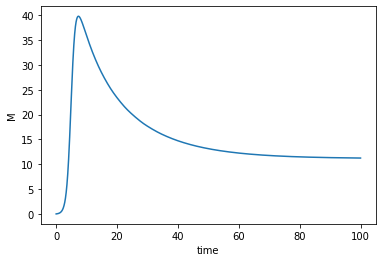

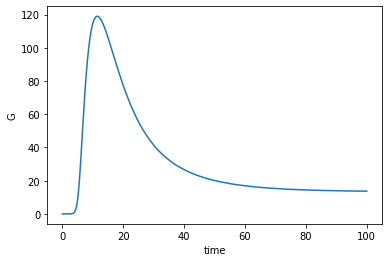

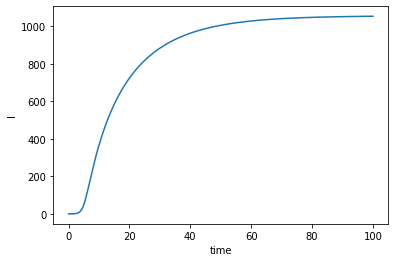

In [66]:
###ANSWER###

plt.figure(1)
plt.plot( t, M )
plt.xlabel( "time" )
plt.ylabel( "M" )
plt.show()

plt.figure(2)
plt.plot( t, G )
plt.xlabel( "time" )
plt.ylabel( "G" )
plt.show()

plt.figure(3)
plt.plot( t, I )
plt.xlabel( "time" )
plt.ylabel( "I" )
plt.show()

###ANSWER###

## Part 2. Solving differential equations numerically (20 total points)

[Back to Top](#toc)

In previous assignments, you have used `solve_ivp` to compute the numeric solution of the logistic model of the growth of a single population. Recall, the Logistic population model is described by the following differential equations:

\begin{equation}
\frac{dP}{dt} = kP\Big(1-\frac{P}{C}\Big),
\end{equation}

where $P =$ population, $k =$ growth rate, and $C =$ the carrying capacity. 

Examples code for computing the solution for for $P_0 =0.1$ billion (initial population), $k=1$, and $C =1$ billion is provided below:

In [27]:
# example code to compute a numeric solution of the logistic model
import numpy as np
from scipy.integrate import solve_ivp

# define the derivative
def logistic(time, current_state):
    p = current_state   
    dpdt = p*(1-p)    
    return dpdt

# compute numeric solution
initial_p = [0.1]
time = np.linspace(0,10,50)

result = solve_ivp(logistic, (0,20), initial_p, t_eval = time)

# unpack solution
numerical_p = result.y[0,:]

The above was a logistic model for a single species. Now let's consider a two-variable system, represented by two coupled (linked) differential equations. 

A classic example of a two-variable system is a bead on a rotating hoop. Imagine a circular wire hoop standing vertically that is spinning at a constant angular velocity *v* around its vertical diameter. A small, frictionless bead is threaded onto the hoop.
As the hoop spins, two main forces act on the bead: **gravity** (pulling it down) and **centrifugal force** (pushing it outward away from the axis of rotation). Depending on how fast the hoop spins, the bead will either settle at the very bottom or "climb" up the side of the hoop to a specific angle.

To describe this system, we use the angle *a* (the position of the bead relative to the bottom) and its angular velocity (*v*). The dynamics are defined by the following two first-order differential equations:

$$ \frac{da}{dt} = v $$

(The rate of change of the angle *a* is the angular velocity *v*.)

$$ \frac{dv}{dt} = \sin(a)*(v^2*\cos(a) - g/r) $$  


(The rate of change of the angular velocity *v* depends on the balance between centrifugal force and gravity, where *g* is gravity and *r* is the hoop's radius.)

**Your job for this part of the assignment is implementing and computing the numeric solutions for the two-variable bead on a rotating hoop model as described by the two equations above. You can do so by adapting the code for the logistic model above.**

&#9989;&nbsp; **Part 2.1 (8 points)**  
Define the derivatives function for the two-variable bead on a rotating hoop model in the cell below (to be used as an input later for `solve_ivp` -- so pay attention to the format). 

The function should take in the time, a current-state vector containing the angle `a` and the angular velocity `v`, and return the derivatives of the angle and angular velocity. It will also take in the parameters `g`  and `r` for the gravity and the radius of the hoop, respectively.

In [31]:
# write your function here


In [33]:
### ANSWER

def bead_on_hoop(time, current_state, g, R):
    a, v = current_state[0], current_state[1]

    dadt = v
    dvdt = np.sin(a) * (v**2 * np.cos(a) - g/R)

    return [dadt, dvdt]


## rubric
# 2 pts for any attempt at defining a function
# 2 pts for getting input argument positions correct
# 1 pt for unpacking current_state correctly
# 1 pt for returning du dv correctly
# 2 pts for defining the equations correctly

&#9989;&nbsp; **Part 2.2 (6 points)**

Using `solve_ivp`, compute the numeric solution for two rotating-hoop model with: 

* the parameters Gravity $g = 9.81$  ($m/s^2$), and radius of the hoop $r=1.0$ ($m$),
* initial conditions $[a_0,v_0]= [0.1, 0.0]$, 
* the final time = $20$ ($s$). 

Unpack the result you get from `solve_ivp` into separate variables `a` and `v`.

In [36]:
# put your code here


In [38]:
### ANSWER
a= 0.1
v= 0.0
initial_conditions = [a,v]  # initial conditions
g = 9.81
R = 1.0

time = np.linspace(0,50,1000)

result = solve_ivp(bead_on_hoop, (0,50),initial_conditions, t_eval = time, args=(g, R))

a = result.y[0,:]
v = result.y[1,:]

## Rubric
# 2 pts for defining parameters and initial conditions correctly
# 1 pt for defining time array
# 2 pts for calling solve_ivp correctly
# 1 pt for unpacking the results

&#9989;&nbsp; **Part 2.3 (4 points)**

Plot the solutions of $a$ and $v$ as a function of time in the cell below. Be sure to add appropriate axis labels and legends, and a plot title.

In [41]:
# put our code here


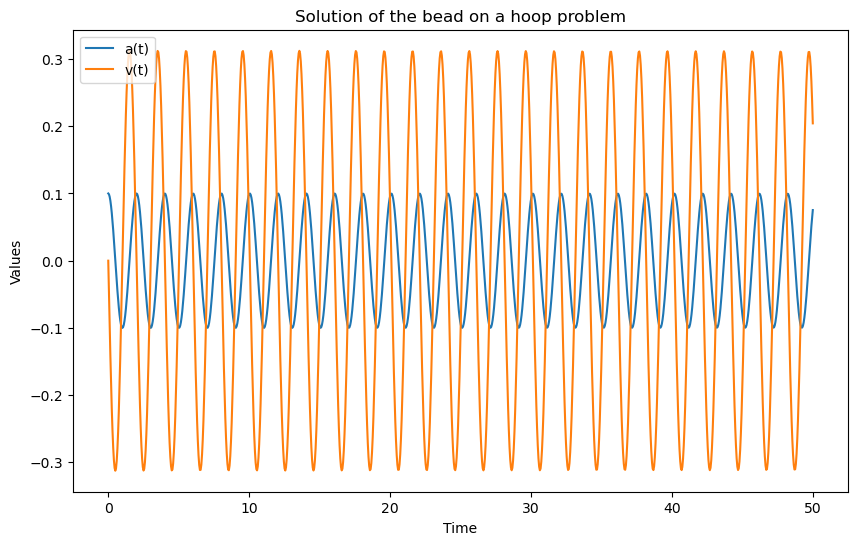

In [43]:
### ANSWER
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(time, a, label='a(t)')
plt.plot(time, v, label='v(t)')

plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.title('Solution of the bead on a hoop problem')

plt.show()

## Rubric
# 2 pts for plotting the two lines correctly
# 2 pts for axis labels and legends

&#9989;&nbsp; **Part 2.4 (2 points)**

What happens when you run the model longer? Does the pattern of time evolution change for either $a(t)$ or $v(t)$?

&#9998; *Put your answer here*

### ANSWER


<a id="part_3"></a>
## Part 3. Interpreting model behavior for different parameters and initial conditions  (15 total points)

In part 2, the parameter values you were given generated the "Subcritical Regime" where the bead oscillated back and forth. ($w < \sqrt{g/R}$)

In this part, you will re-run the model under a couple of different scenarios and initial conditions, and interpret these plots.

&#9989;&nbsp; **Part 3.1 (4 points)** Supercritical Regime

Let us pick a value of $w$ that is greater than $\sqrt{g/R}$, and re-run the model.

Rerun your code from part 2.2 and regenerate the plots from part 2.3, but this time let $w = 3.5$.

In [74]:
# Put your code to call `solve_ivp` here


In [75]:
# Put your code to plot the solution here

In [76]:
### ANSWER
a= 0.1
v= 3.5
initial_conditions = [a,v]  # initial conditions
g = 9.81
R = 1.0

time = np.linspace(0,20,1000)

result = solve_ivp(bead_on_hoop, (0,20),initial_conditions, t_eval = time, args=(g, R))

a = result.y[0,:]
v = result.y[1,:]

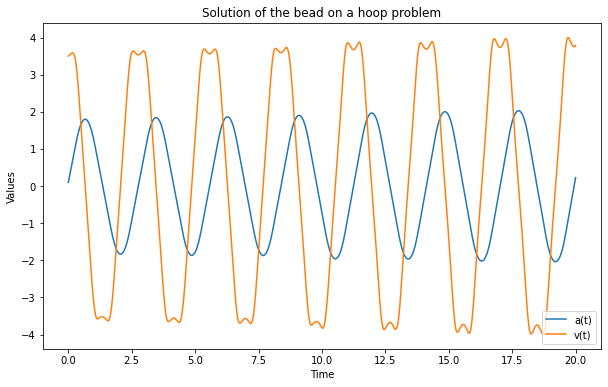

In [77]:
### ANSWER
plt.figure(figsize=(10, 6))

plt.plot(time, a, label='a(t)')
plt.plot(time, v, label='v(t)')

plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.title('Solution of the bead on a hoop problem')

plt.show()

&#9989;&nbsp; **Part 3.2 (3.5 points)**
How did the behavior of the system change? Do you still see oscillations in $a(t)$ and $v(t)$? 

&#9998; *Put your answer here*

&#9989;&nbsp; **Part 3.3 (4 points)** High-Speed Limit

Let us now pick a value of $w$ that is **much greater** than $\sqrt{g/R}$, and re-run the model.

Rerun your code from parts 2.2 and 2.3, but this time let $w = 6$.

In [17]:
# Put your code to call `solve_ivp` here


In [19]:
# Put your code to plot the solution here

In [45]:
## ANSWER
a= 0.1
v= 6.0
initial_conditions = [a,v]  # initial conditions
g = 9.81
R = 1.0

time = np.linspace(0,20,1000)

result = solve_ivp(bead_on_hoop, (0,20),initial_conditions, t_eval = time, args=(g, R))

a = result.y[0,:]
v = result.y[1,:]

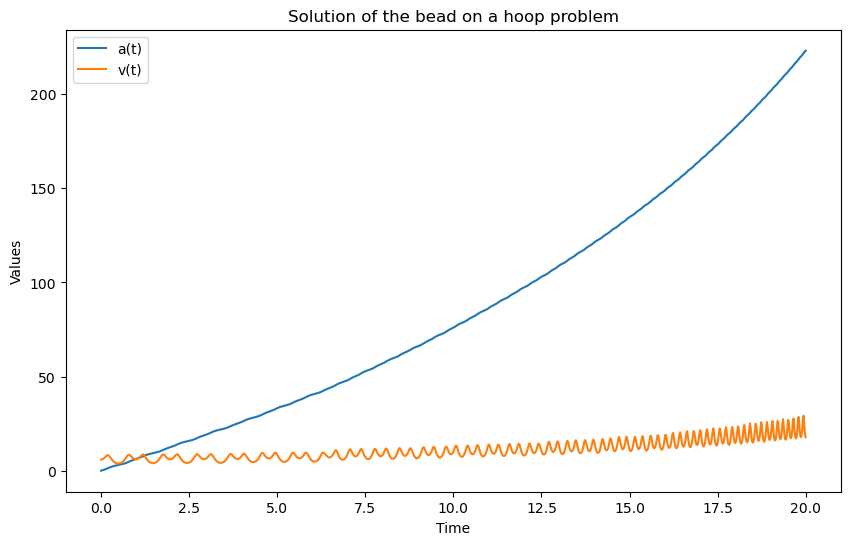

In [47]:
### ANSWER
plt.figure(figsize=(10, 6))

plt.plot(time, a, label='a(t)')
plt.plot(time, v, label='v(t)')

plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.title('Solution of the bead on a hoop problem')

plt.show()

&#9989;&nbsp; **Part 3.4 (3.5 points)**
How did the behavior of the system change this time? Do you still see oscillations in $a(t)$ and $v(t)$? 

&#9998; *Put your answer here*

<a id="part_4"></a>
## Part 4. Data Visualization for NYC’s "Vision Zero" Initiative

In 2014, New York City launched **Vision Zero**, an ambitious plan to eliminate all traffic-related fatalities and serious injuries. The city has significantly invested in "traffic calming" measures, lower speed limits, and thousands of automated speed cameras. However, the path to zero has been bumpy.

You have been tasked with analyzing the raw NYPD collision data to see if the streets of New York are actually getting safer, or if the "Vision Zero" goal remains elusive.

&#9989;&nbsp; **Part 4.1 (4 points)** Data Context

You found the collision data on the [NYC Open Data portal](https://catalog.data.gov/dataset/motor-vehicle-collisions-crashes). Briefly contextualize the data in the cell below by answering the following:

* **Who** collected/generated the data?
* **How** was the data collected/generated?
* **Who/what** is included in the data?
* **What** are the limitations or biases of the data?

&#9998; *Put your answer here*

### ANSWER 

* **Who collected/generated the data?**
    The NYPD (New York City Police Department).
* **How was the data collected/generated?**
    Police officers fill out the MV-104AN form for each crash. Since March 2016, it has been entered electronically using the FORMS system.
* **Who/what is included in the data?**
    All police-reported motor vehicle collisions in NYC where someone was injured or killed, or where there was at least \$1,000 worth of damage.
* **Who/what is not included in the data?**
    Minor "fender-benders" that result in less than \$1,000 of property damage and no injuries are not required to be reported. 
* **What are the limitations or biases of the data?**
    The data is preliminary and subject to change. There is a "technological shift" bias where data after 2016 is likely more complete due to the switch to electronic entry.

---

### Rubric (4 Points Total)

* **1 pt:** Correctly identifies the **NYPD** as the source and/or the **MV-104AN** form as the method.
* **1 pt:** Correctly identifies NYPD officiers complete a form.
* **1 pt:** Correctly identifies the inclusion criteria (**injury, death, or \$1,000+ damage**).
* **1 pt:** Identifies a valid limitation (e.g., **preliminary nature**, **electronic vs manual entry**, or **under-reporting of minor crashes**).

&#9989;&nbsp; **Part 4.2 (4 points)** Loading and cleaning data

Now that you know the context of the data, it's time to read it into your notebook and prepare it for analysis. Because the original dataset is massive (over 2 million rows), we are working with a **sampled subset** of 5,000 crashes. However, this sample is still "raw" and requires cleaning.

In the cell below:
1.  Read in the data file `nypd_collisions_sample.csv`. 
2.  Remove any rows where **'BOROUGH'** is NaN and save this as a new dataframe.
3.  Drop the columns **'CONTRIBUTING FACTOR VEHICLE 3'**, **'CONTRIBUTING FACTOR VEHICLE 4'**, and **'CONTRIBUTING FACTOR VEHICLE 5'** from your new dataframe.
4.  Display the `.shape`,and the `.head()` of your cleaned dataframe.

If your cleaning worked correctly, you should have roughly **3,500 rows** and **19 columns** remaining.

In [82]:
# put your code here


In [83]:
### ANSWER 

import pandas as pd

# 1. Load data
df = pd.read_csv('nypd_collisions_sample.csv')

# 2. Remove NaN Boroughs
df_cleaned = df.dropna(subset=['BOROUGH'])

# 3. Drop columns
df_cleaned = df_cleaned.drop(columns=['CONTRIBUTING FACTOR VEHICLE 3', 
                                      'CONTRIBUTING FACTOR VEHICLE 4', 
                                      'CONTRIBUTING FACTOR VEHICLE 5'])

# 4. Display results
print(df_cleaned.shape)
df_cleaned.head()


# Rubric:
#  1 pt for reading csv with pandas
#  1 pts for correctly dropping rows with NaN in 'BOROUGH' 
#  1 pt for dropping the 3 specific 'CONTRIBUTING FACTOR' columns
#  1 pt for displaying .shape, .head()

(3503, 19)


,YEAR,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2
0,2012,2012-07-01,12:52,BROOKLYN,11213.0,40.668798,-73.931120,0.0,0.0,0,0,0,0,0,0,Driver Inattention/Distraction,Unspecified,PASSENGER VEHICLE,SPORT UTILITY / STATION WAGON
1,2012,2012-07-02,9:48,MANHATTAN,10075.0,40.773642,-73.959856,0.0,0.0,0,0,0,0,0,0,Other Vehicular,Failure to Yield Right-of-Way,AMBULANCE,PASSENGER VEHICLE
2,2012,2012-07-03,19:00,STATEN ISLAND,10304.0,40.594048,-74.099492,0.0,0.0,0,0,0,0,0,0,Unspecified,Unspecified,PASSENGER VEHICLE,UNKNOWN
4,2012,2012-07-03,10:00,BRONX,10468.0,40.868750,-73.894963,0.0,0.0,0,0,0,0,0,0,Unspecified,Unspecified,PASSENGER VEHICLE,PASSENGER VEHICLE
5,2012,2012-07-03,22:30,MANHATTAN,10016.0,40.747078,-73.981341,0.0,0.0,0,0,0,0,0,0,Unspecified,Unspecified,PASSENGER VEHICLE,PASSENGER VEHICLE


&#9989;&nbsp; **Part 4.3 (4 points)** Choosing a question and getting the data

Recall the key pieces to an effective data visualization (from the Day 20 Pre Class and In Class assignments). There are many ways to look at this crash data to see if NYC's "Vision Zero" goals are being met. For this section, you will choose **one** of the following Research Questions (RQ) to explore:

* **RQ 1:** How does the total number of persons injured compare across the five boroughs for the most recent complete year in our data (2025)?
* **RQ 2:** Compare the number of "Pedestrians Injured" vs. "Cyclists Injured" for each borough. Which borough appears to have the highest "non-motorist" injury count in this sample?
* **RQ 3:** Choose one specific borough (e.g., Brooklyn, Manhattan, etc.). How has the total number of injuries changed year-over-year from 2014 to 2025?

**In the cells below:**
1.  Indicate which question you are going to explore.
2.  Using your clean data set, extract the data necessary for answering your question (i.e., use **masking** to extract data, remove rows or columns you will not use, etc.).
3.  Display the first few rows of your extracted data subset.

<font size=6 color="#009600">&#9998;</font> *Write down your choice and specify the variables involved.*

In [84]:
# put your code here to extract a subset of data relevant to your question


In [85]:
### ANSWER 

### EXAMPLE CODE (For RQ 1: Injuries in 2025)
data_2025 = df_cleaned[df_cleaned['YEAR'] == 2025]
rq1_subset = data_2025[['BOROUGH', 'NUMBER OF PERSONS INJURED']]
rq1_subset.head()


# Rubric:
#  2 pts for choosing a question and correctly identifying the variables needed
#  1 pt for an attempt at masking 
#  1 pt for masking/logic that aligns with the chosen question 

,BOROUGH,NUMBER OF PERSONS INJURED
4761,BROOKLYN,0.0
4762,QUEENS,0.0
4763,BRONX,1.0
4765,BROOKLYN,1.0
4766,BRONX,0.0


In [86]:
### EXAMPLE CODE (For RQ 2: Pedestrians vs Cyclists)
rq2_subset = df_cleaned[['BOROUGH', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED']]
rq2_subset.head()

,BOROUGH,NUMBER OF PEDESTRIANS INJURED,NUMBER OF CYCLIST INJURED
0,BROOKLYN,0,0
1,MANHATTAN,0,0
2,STATEN ISLAND,0,0
4,BRONX,0,0
5,MANHATTAN,0,0


In [87]:
### EXAMPLE CODE (For RQ 3: Time trend for one borough)
manhattan_data = df_cleaned[df_cleaned['BOROUGH'] == 'MANHATTAN']
rq3_subset = manhattan_data[['YEAR', 'NUMBER OF PERSONS INJURED']]
rq3_subset.head()

,YEAR,NUMBER OF PERSONS INJURED
1,2012,0.0
5,2012,0.0
14,2012,1.0
23,2012,0.0
33,2012,0.0


&#9989;&nbsp; **Part 4.3 (8 points)** Making a Plot

Now that you have extracted the specific data you need, it's time to create a visualization! Using the plotting tools we have explored in class (`matplotlib.pyplot` or `seaborn`), create a plot that answers your chosen Research Question. 

**Your plot will be graded based on the following rubric:**
* **Does the plot tell a story? (4 Points):** Is it clear what the data is showing and how it answers your RQ?
* **Chart type (2 points):** The chart type is appropriate, and the data is easy to read.
* **Labels, legend, and title (1 point):** Are they informative without being cluttered?
* **Presenting multi-variable data (1 point):** Did you effectively use colors, markers, or grouping to show different categories?

In [88]:
# put your code here to create a plot


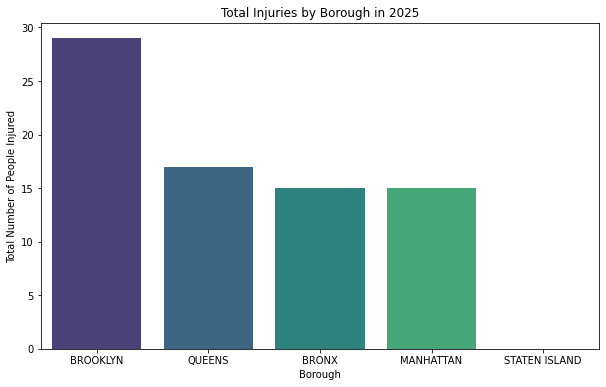

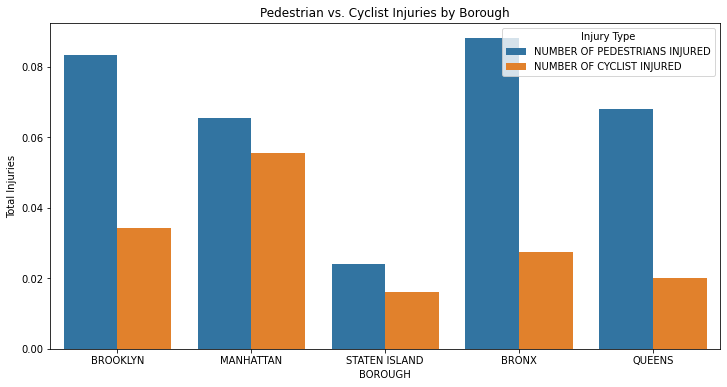

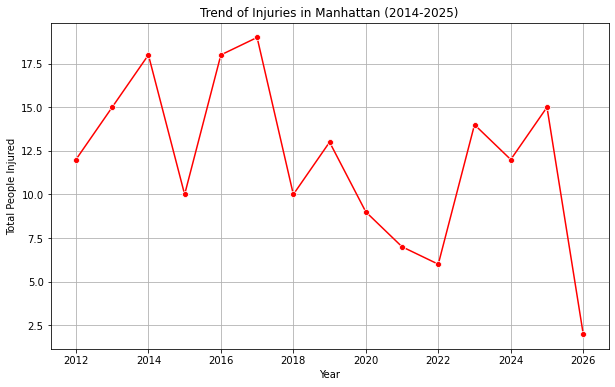

In [94]:
### ANSWER 

import matplotlib.pyplot as plt
import seaborn as sns

### EXAMPLE PLOT (For RQ 1: Injuries by Borough in 2025)
# Using the 'data_2025' subset from the previous part
plt.figure(figsize=(10,6))
sns.barplot(data=data_2025, x='BOROUGH', y='NUMBER OF PERSONS INJURED', estimator=sum, ci=None, palette='viridis')
plt.title('Total Injuries by Borough in 2025')
plt.ylabel('Total Number of People Injured')
plt.xlabel('Borough')
plt.show()

### EXAMPLE PLOT (For RQ 2: Pedestrians vs Cyclists)
# We plot two types of injuries side-by-side
melted_rq2 = rq2_subset.melt(id_vars='BOROUGH', value_vars=['NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED'])

plt.figure(figsize=(12,6))
sns.barplot(data=melted_rq2, x='BOROUGH', y='value', hue='variable', ci=None)
plt.title('Pedestrian vs. Cyclist Injuries by Borough')
plt.ylabel('Total Injuries')
plt.legend(title='Injury Type')
plt.show()

### EXAMPLE PLOT (For RQ 3: Trend in Manhattan)
# Using 'manhattan_data' 
plt.figure(figsize=(10,6))
# We group by year to get the sum of injuries per year
yearly_trend = manhattan_data.groupby('YEAR')['NUMBER OF PERSONS INJURED'].sum().reset_index()
sns.lineplot(data=yearly_trend, x='YEAR', y='NUMBER OF PERSONS INJURED', marker='o', color='red')
plt.title('Trend of Injuries in Manhattan (2014-2025)')
plt.ylabel('Total People Injured')
plt.xlabel('Year')
plt.grid(True)
plt.show()

# Rubric:
#  4 pts: Storytelling (The plot directly addresses the RQ chosen in 4.3)
#  2 pts: No wasted space (e.g., didn't use a line plot for categorical data)
#  1 pt: Informative labels (Title, X-label, Y-label)
#  1 pt: Multi-variable data (Used hue, different bars, or markers correctly)

## Part 5. Data Interpretation

Now that you have explored your own subset of the data, it is time to look at the "Big Picture." Below are some figures generated using the full dataset of over 2.2 million records. 

In this final section, you will step into the shoes of an NYC Policy Analyst working on the **Vision Zero** initiative. 

&#9989;&nbsp; **Part 5.1 (6 points)** Data Artifacts

Analyze the plots below and answer the following questions.

**1. The 2012 "Rise" (2 points):**
In both plots there is a massive jump between 2012 and 2013. What might be the cause of that? 

**2. The 2026 "Cliff" (2 points):**
What explains the dramatic drop-off that both plots show in 2026?

**2. Progress (2 points):**
From these plots, do you think the Vision Zero initiative has been successful? 

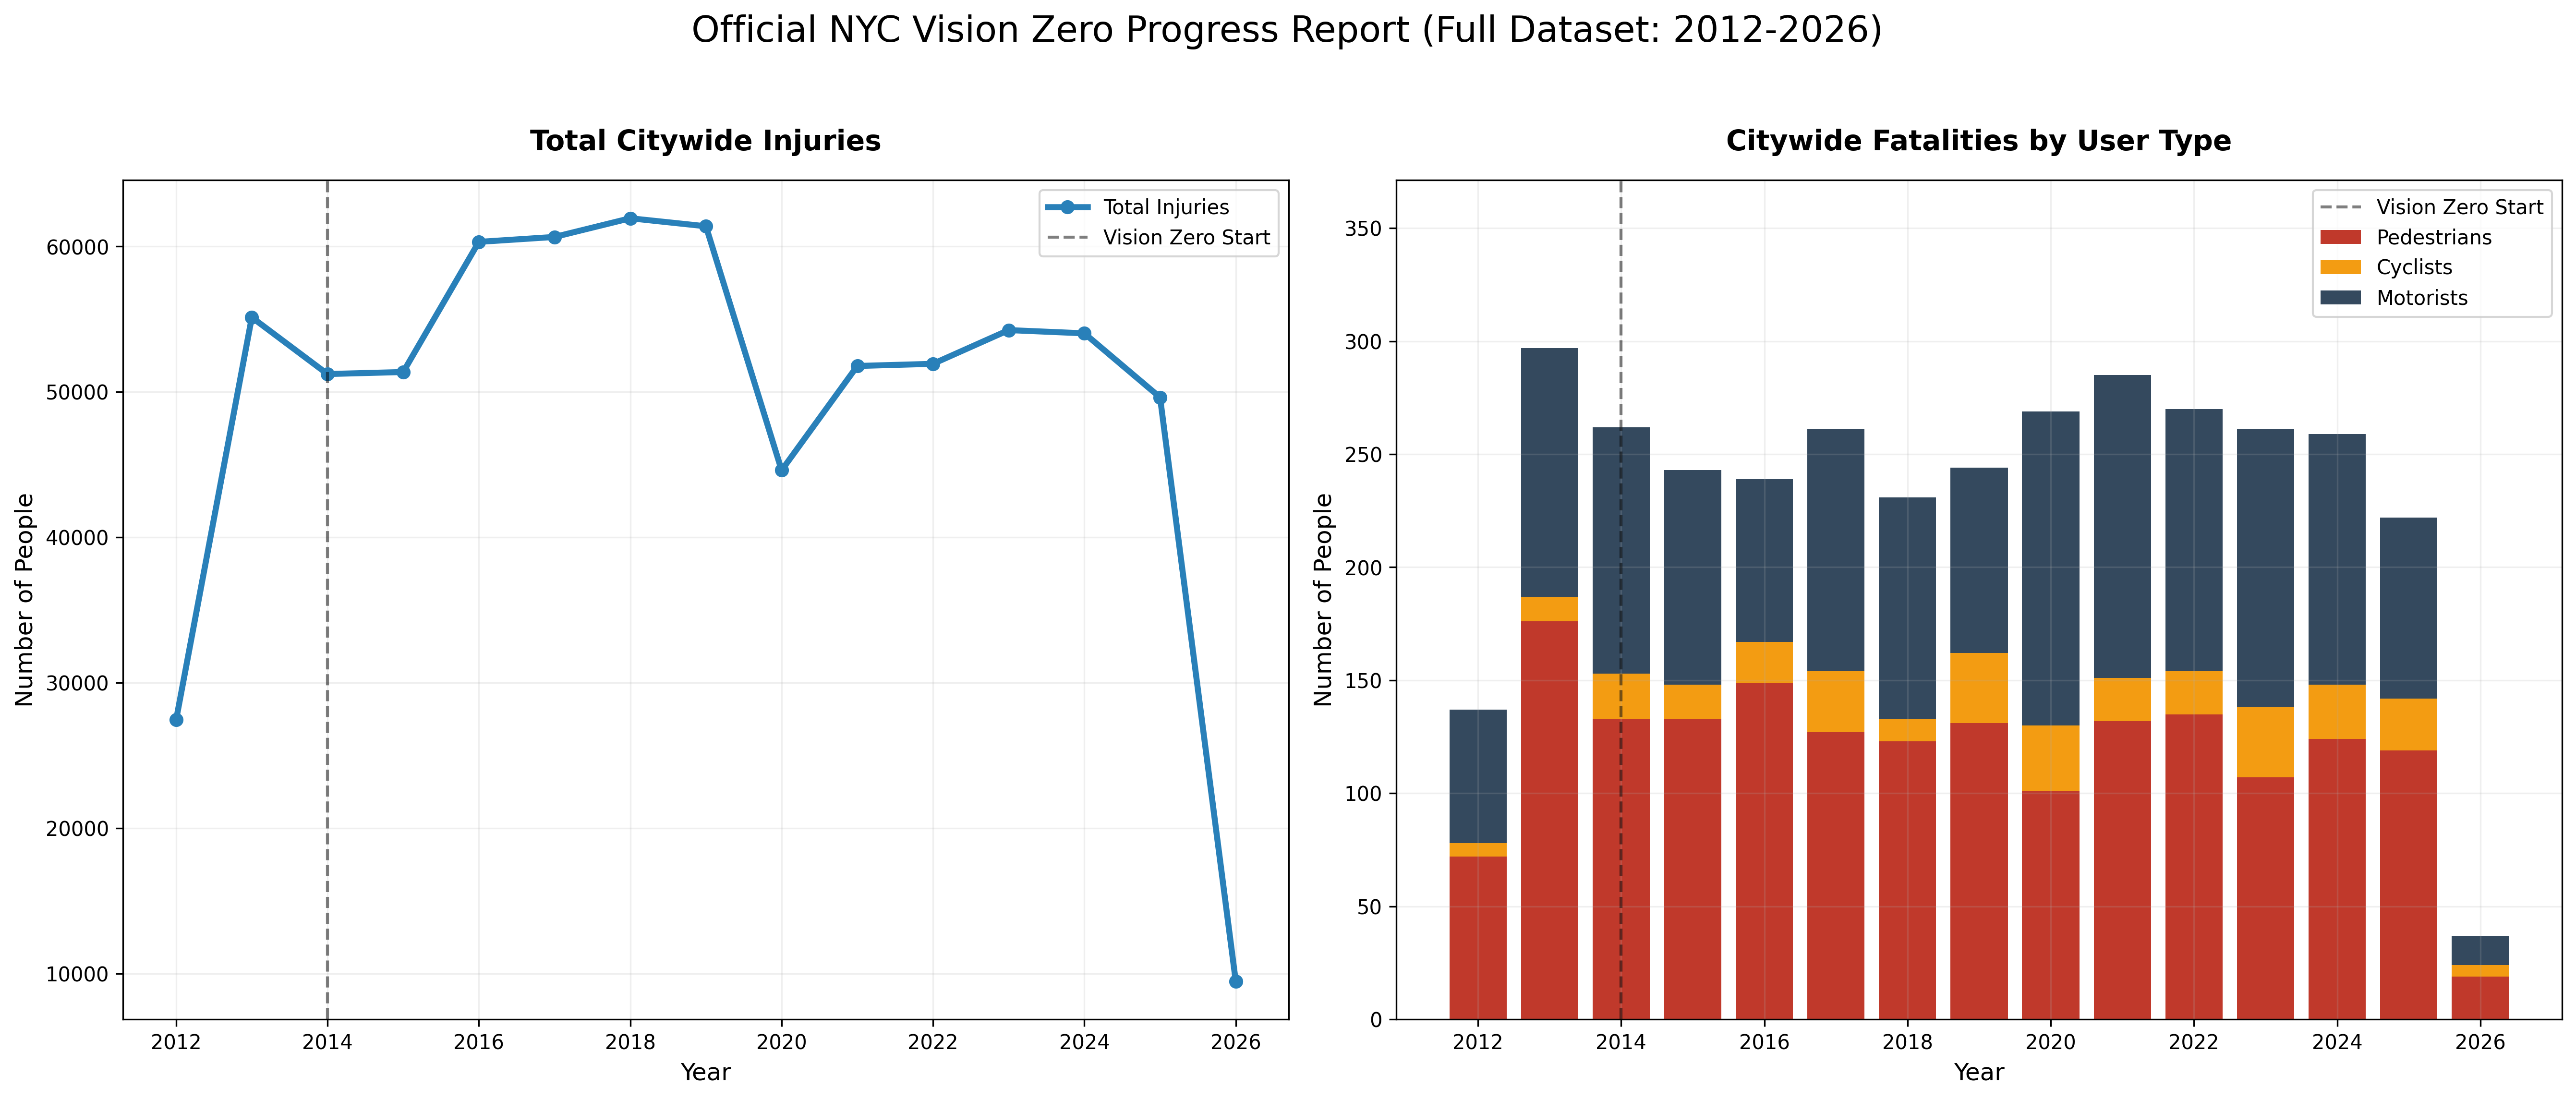

In [90]:
from IPython.display import Image
# Load the official report saved from the full dataset analysis
Image(filename='vision_zero_report.png')

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### ANSWER 

**1. The 2012 "Rise"** is a **reporting artifact**, not a literal surge in crashes. In July 2012, NYC transitioned to an electronic "Open Data" reporting system. Because 2012 only contains a partial year of digital records, 2013 appears as a massive spike simply because it represents the first full 12-month calendar year of digitized data.

**2. The 2026 "Cliff"**
The dramatic drop-off in 2026 is due to **incomplete data**. Since we are currently in March 2026, the dataset only reflects the first ~3 months of the year. The "cliff" exists because the remaining 9 months of the year haven't happened yet, it is not a sign of a sudden 90% drop in traffic incidents.

**3. Progress: Is Vision Zero Successful?**
**No (or Inconclusive).** While Vision Zero (started in 2014) aimed for *zero* deaths, the "Citywide Fatalities" plot shows that numbers have largely plateaued for over a decade. 

---

### Rubric (6 Points Total)

* **2 pt:** Correctly identifies the 2012/2013 jump as a reporting change or partial year of data 
* **2 pt:** Correctly identifies that the year 2026 is still in progress (incomplete data through March).
* **2 pt:** Provides a "No" or "Inconclusive" verdict and cites evidence from the plots 

&#9989;&nbsp; **Part 5.2 (4 points) When do crashes occur?** 

To truly understand traffic safety, we must also investigate when they occur. The following heatmap provides a look at a typical week. 

**1. Dangerous Hours (2 points)**
What seem to be some of the most dangerous times of day? Why do you think that is?

**2. Policy & Prevention (2 points)**
If a "Vision Zero" task force could only implement one safety intervention for four hours a week, which specific blocks on this heatmap should they target to have the greatest impact?

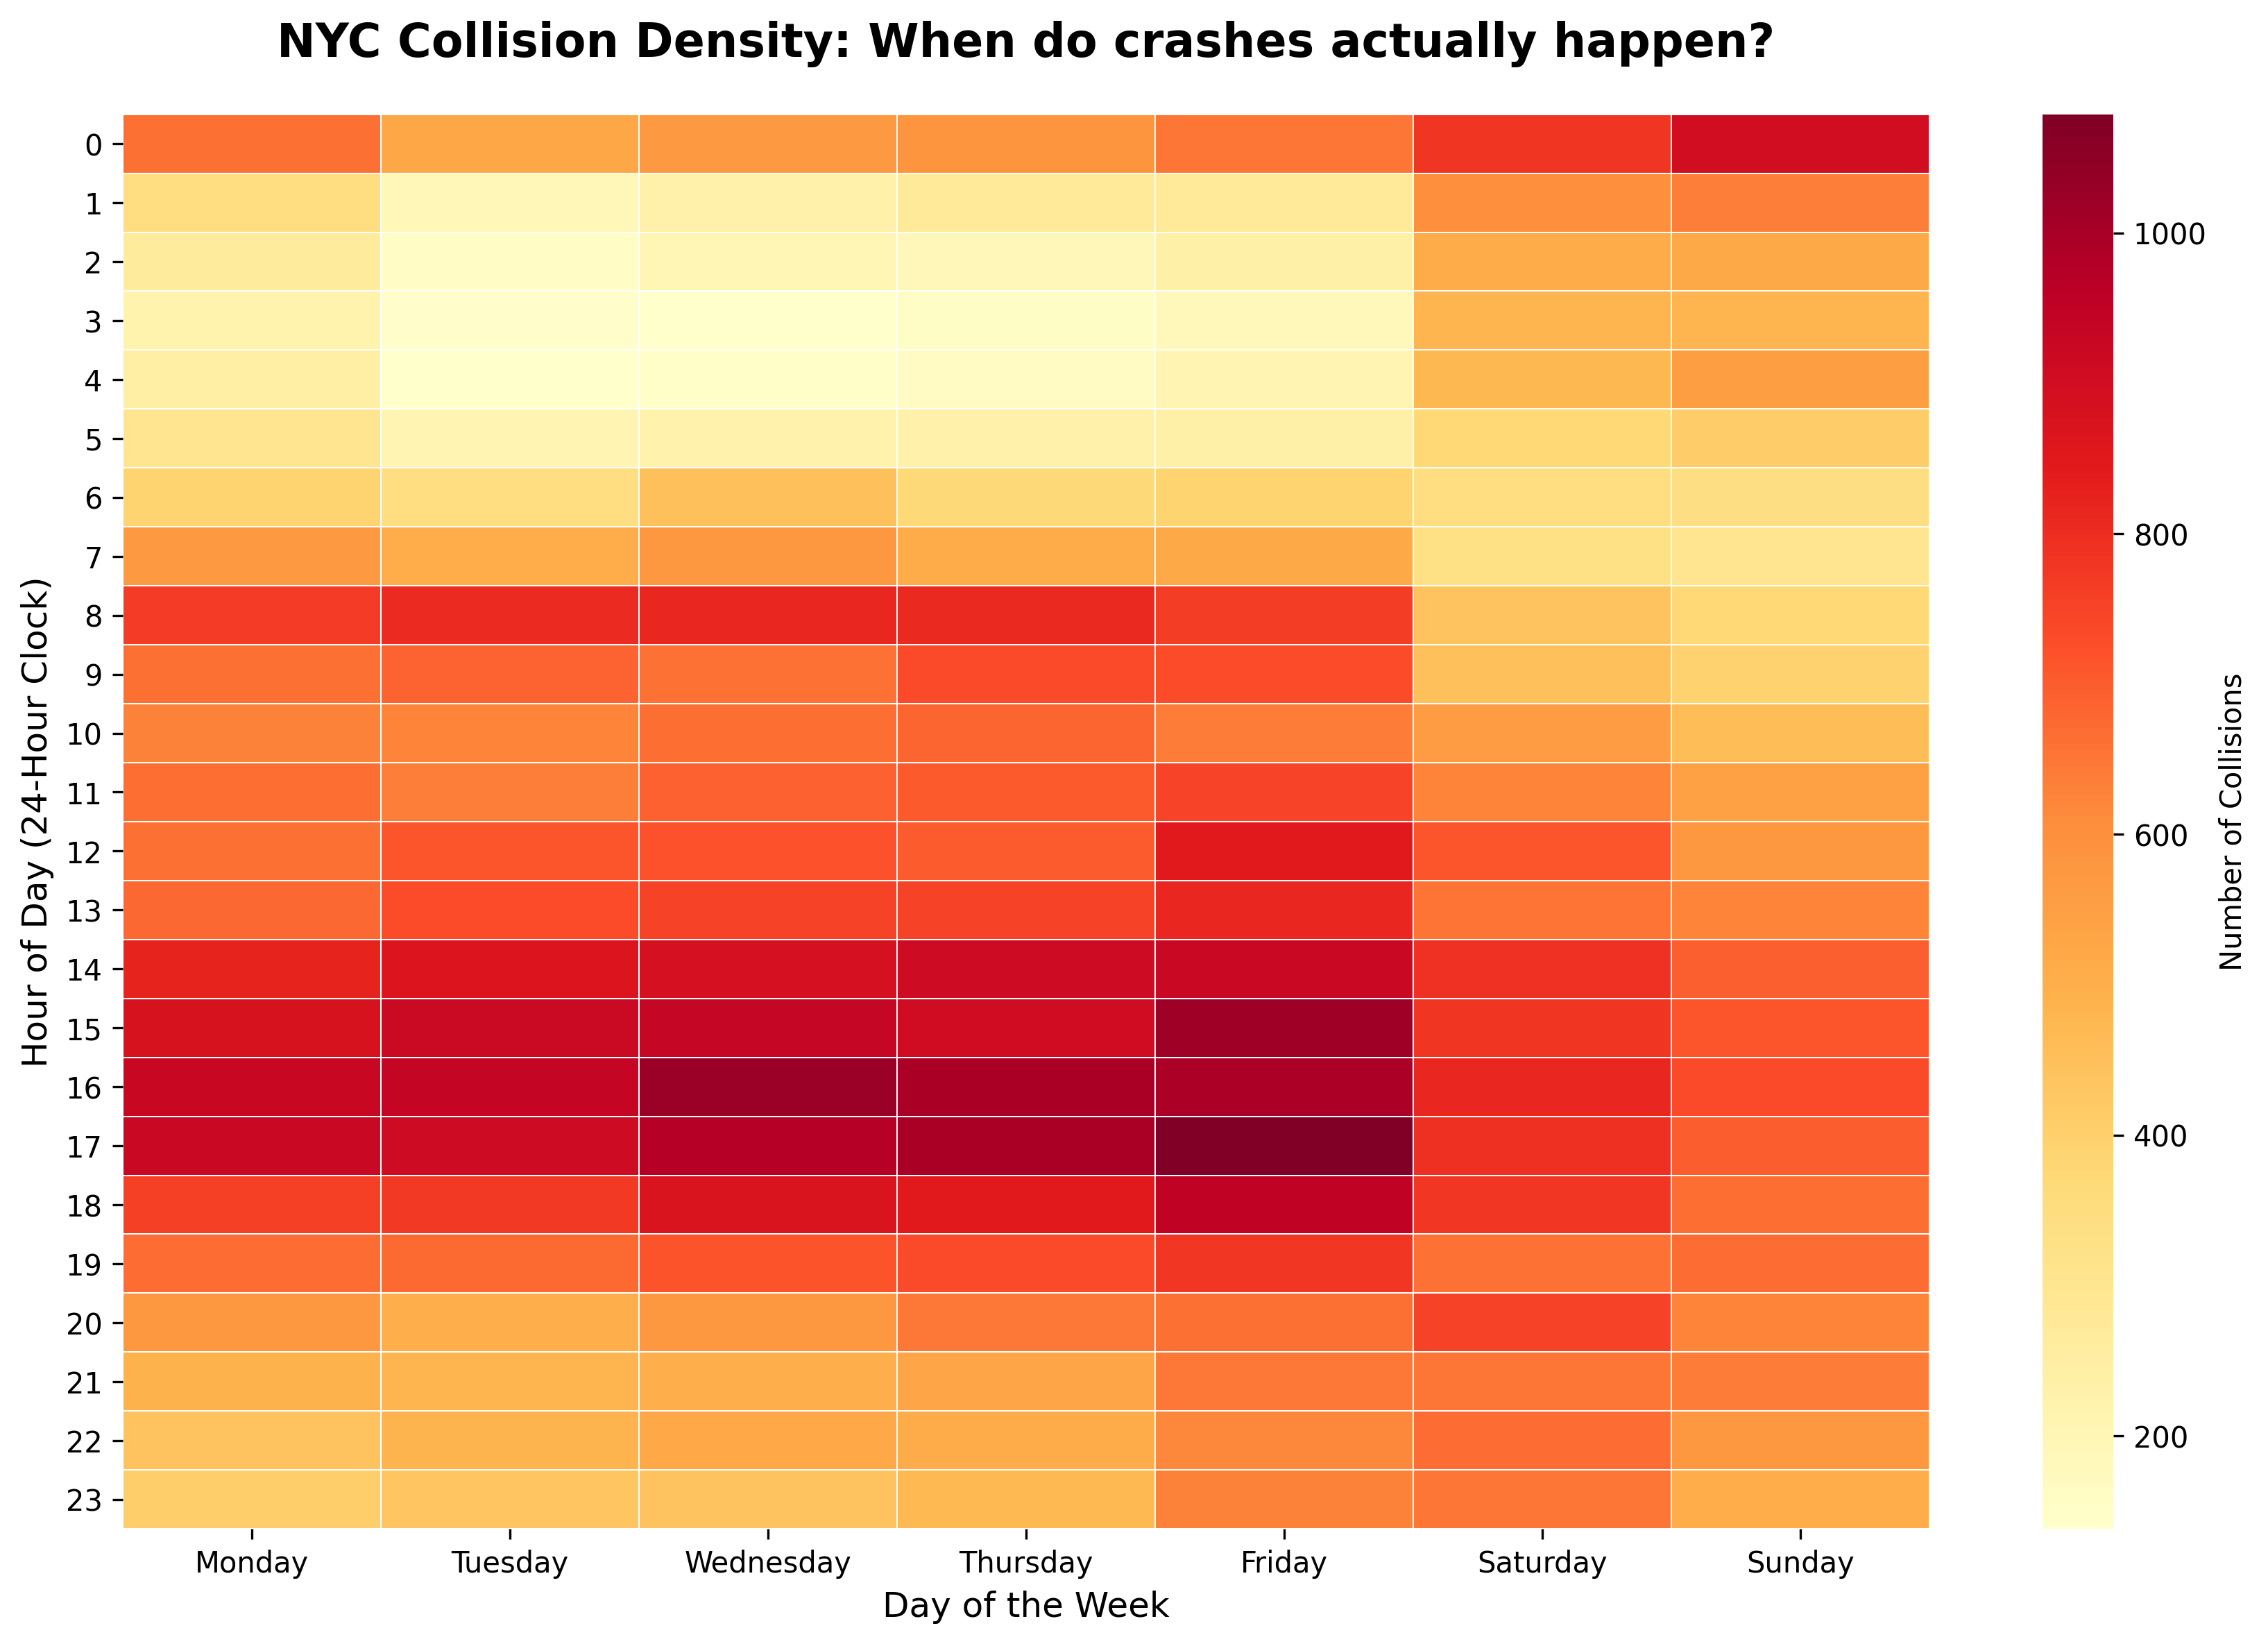

In [91]:
from IPython.display import Image
# Load the official report saved from the full dataset analysis
Image(filename='heat_map.png')

&#9998; *Put your answer here*

### ANSWER

* **Dangerous Hours:** The most dangerous time of day is the evening rush hour, specifically from **3:00 PM to 7:00 PM (Hours 15–18)**. The absolute peak occurs on **Friday at 5:00 PM (Hour 17)**. This likely happens because of driver fatigue at the end of the day, school dismissals overlapping with work commutes, and the "weekend getaway" rush.
* **Policy & Prevention:** The task force should target the **Friday 3:00 PM to 7:00 PM (Hours 15–18)** block. Since this is the highest density of collisions on the map.

---

### Rubric (4 Points Total)

* **2 pts:** Correctly identifies the morning and weekday evening rush (or specifically Friday afternoon) as the most times.
* **2 pt:** Identifies the specific 4-hour block of **Friday 15:00–19:00** as the target for intervention.

&#9989;&nbsp; **Part 5.3 (6 points) Why do crashes occur?** 

To reach the goal of "Zero," we must also understand the cause. The visualization below explores the **"Why."** By ranking the primary contributing factors reported by the NYPD, we can identify whether the biggest threats to New Yorkers are rooted in road infrastructure or individual driver behavior.

**1. Policy Intervention (2 point)**
If the top factor is "Driver Inattention/Distraction," would building more bike lanes solve this specific problem? Why or why not? What kind of policy (e.g., laws, technology, or education) might be more effective?

**2. The "Unspecified" Gap (2 point)**
In our code, we manually removed the "Unspecified" category. If "Unspecified" were actually the largest category in the dataset, how would that make the job of a safety analyst more difficult?

**3. Vision Zero Goal (2 point)**
Looking at these 10 factors, which one do you think is the hardest for the city to eliminate to reach their goal of zero traffic deaths? Justify your choice.

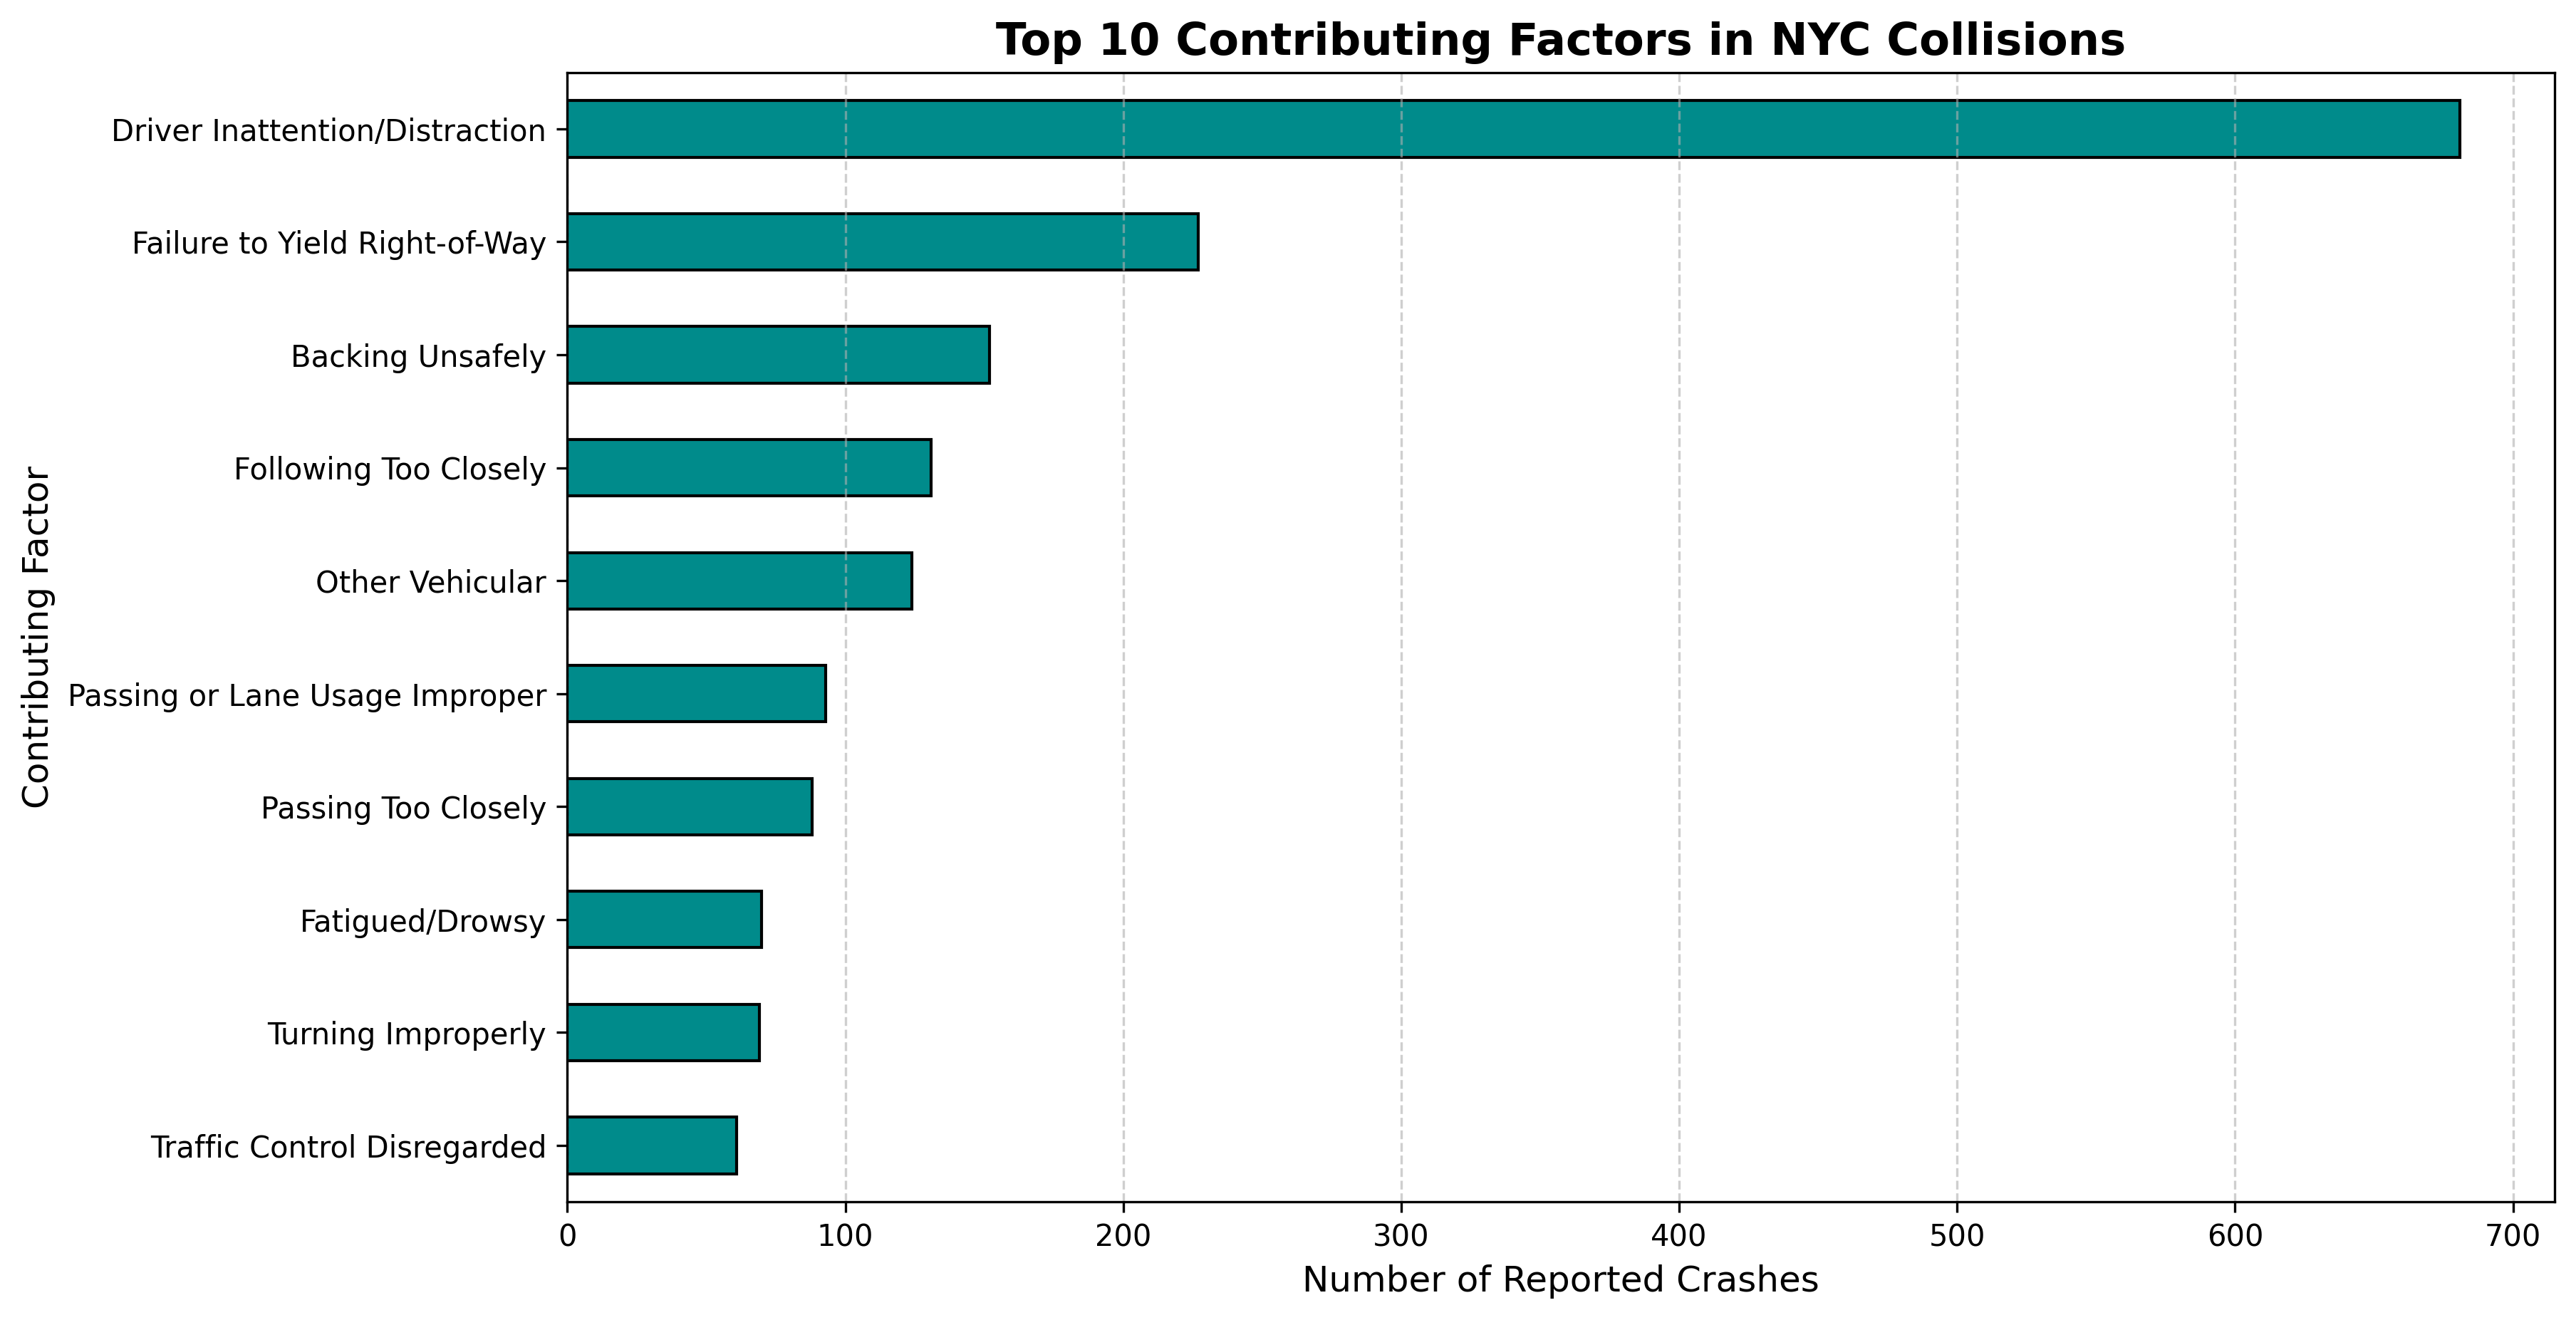

In [92]:
from IPython.display import Image
# Load the official report saved from the full dataset analysis
Image(filename='contributing_factors.png')

&#9998; *Put your answer here*

### ANSWER

* **Policy Intervention:** No, building more bike lanes would not solve the root cause of Driver Inattention/Distraction, as bike lanes are a spatial infrastructure fix for a behavioral problem. While protected lanes might physically separate cyclists from distracted drivers, more effective policies would target the behavior directly, such as stricter "Hands-Free" laws, in-car technology (like driver-attention monitoring systems), or public education campaigns regarding the dangers of phone use while driving.
* **The "Unspecified" Gap:** If "Unspecified" were the largest category, it would make the job of a safety analyst significantly more difficult because the data would lack actionability. You cannot design targeted infrastructure or policy interventions for a "blind spot"; analysts need to know *what* is causing crashes (e.g., speeding vs. distraction) to determine where to allocate the city's limited safety budget.
* **Vision Zero Goal:** Any well justified answer receives points. For example, Driver Inattention/Distraction is likely the hardest to eliminate because it is a pervasive human behavior that occurs inside the private space of a vehicle, making it extremely difficult to monitor or enforce in real-time compared to physical factors like road design. 

---

### Rubric (6 Points Total)

* **2 pts:** Explains that bike lanes address **infrastructure/separation** rather than the **behavioral root** of distraction, and suggests a relevant alternative (e.g., tech, laws, or education).
* **2 pts:** Identifies that "Unspecified" data is not **actionable** or creates a **blind spot** that prevents data-driven decision-making.
* **2 pts:** Points for any well argued selection.

## Congratulations, you're done!

Submit this assignment by uploading your notebook to the course Desire2Learn web page.  Go to the "Homework" folder, find the appropriate submission link, and upload everything there. Make sure your name is on it!

&#169; Copyright 2026,  Department of Computational Mathematics, Science and Engineering at Michigan State University